In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
import time
import warnings
warnings.filterwarnings('ignore')

# Загрузка датасета
# Будем использовать датасет Online Retail от UCI Machine Learning Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
data = pd.read_excel(url)
print("Размер датасета:", data.shape)
data.head()

Размер датасета: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Пропущенные значения:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Процент пропущенных значений:
InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
dtype: float64

Уникальные значения категориальных признаков:
Country: 37
Description: 3877


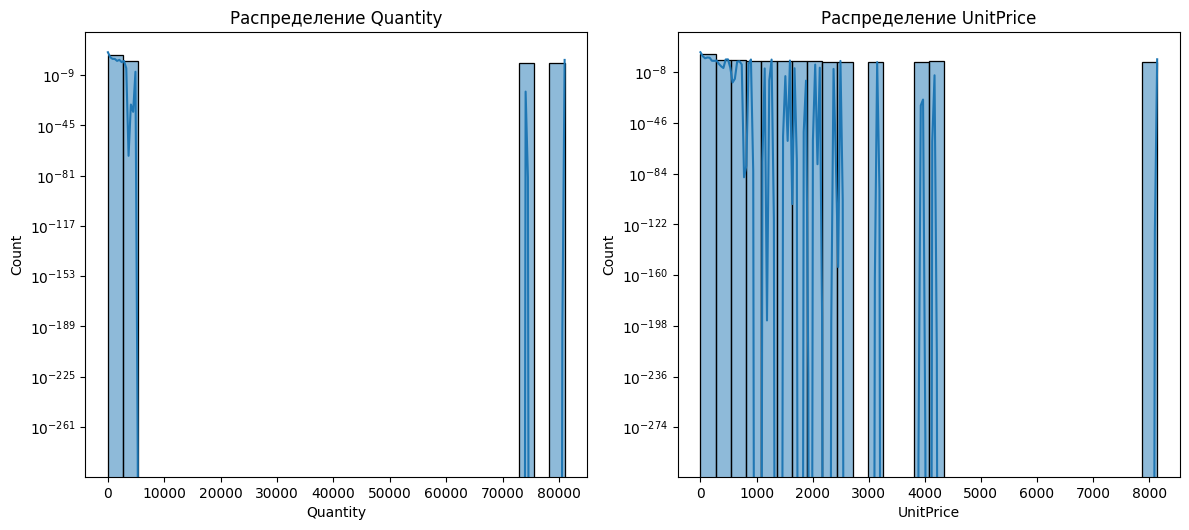

In [21]:
# Анализ пропущенных значений
print("Пропущенные значения:")
print(data.isnull().sum())
print("\nПроцент пропущенных значений:")
print(data.isnull().mean() * 100)

# Анализ категориальных признаков
print("\nУникальные значения категориальных признаков:")
print("Country:", data['Country'].nunique())
print("Description:", data['Description'].nunique())



# Визуализация распределения числовых признаков
plt.figure(figsize=(12, 10))
numeric_cols = ['Quantity', 'UnitPrice']

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.yscale('log')
plt.tight_layout()
plt.show()

# Обработка пропущенных значений и выбросов
# Фильтрация некорректных значений (отрицательные количества)
data = data[data['Quantity'] > 0]
data = data[data['UnitPrice'] > 0]

# Удаление строк с пропущенными значениями в важных столбцах
data = data.dropna(subset=['CustomerID', 'Description'])

# Создание агрегированных признаков по клиентам
customer_data = data.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',  # количество уникальных заказов
    'Quantity': 'sum',       # общее количество товаров
    'UnitPrice': 'mean',     # средняя цена
    'Country': 'first'       # страна
}).rename(columns={
    'InvoiceNo': 'NumOrders',
    'Quantity': 'TotalQuantity',
    'UnitPrice': 'AvgPrice'
}).reset_index()

# Лог-преобразование для признаков с сильной асимметрией
customer_data['LogTotalQuantity'] = np.log1p(customer_data['TotalQuantity'])
customer_data['LogNumOrders'] = np.log1p(customer_data['NumOrders'])
customer_data['LogAvgPrice'] = np.log1p(customer_data['AvgPrice'])

# Подготовка данных для кластеризации
X = customer_data[['LogTotalQuantity', 'LogNumOrders', 'LogAvgPrice', 'Country']]

In [10]:
# Анализ числовых признаков
print("\nСтатистика числовых признаков:")
print(data.describe())


Статистика числовых признаков:
            Quantity                    InvoiceDate      UnitPrice  \
count  397884.000000                         397884  397884.000000   
mean       12.988238  2011-07-10 23:41:23.511023360       3.116488   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 14:39:00       1.950000   
75%        12.000000            2011-10-20 14:33:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       179.331775                            NaN      22.097877   

          CustomerID  
count  397884.000000  
mean    15294.423453  
min     12346.000000  
25%     13969.000000  
50%     15159.000000  
75%     16795.000000  
max     18287.000000  
std      1713.141560  


In [11]:
# Предобработка данных
# Разделение на числовые и категориальные признаки
numeric_features = ['LogTotalQuantity', 'LogNumOrders', 'LogAvgPrice']
categorical_features = ['Country']

# Создание препроцессора
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Применение препроцессора
X_processed = preprocessor.fit_transform(X)

print("Размер обработанных данных:", X_processed.shape)

Размер обработанных данных: (4338, 40)


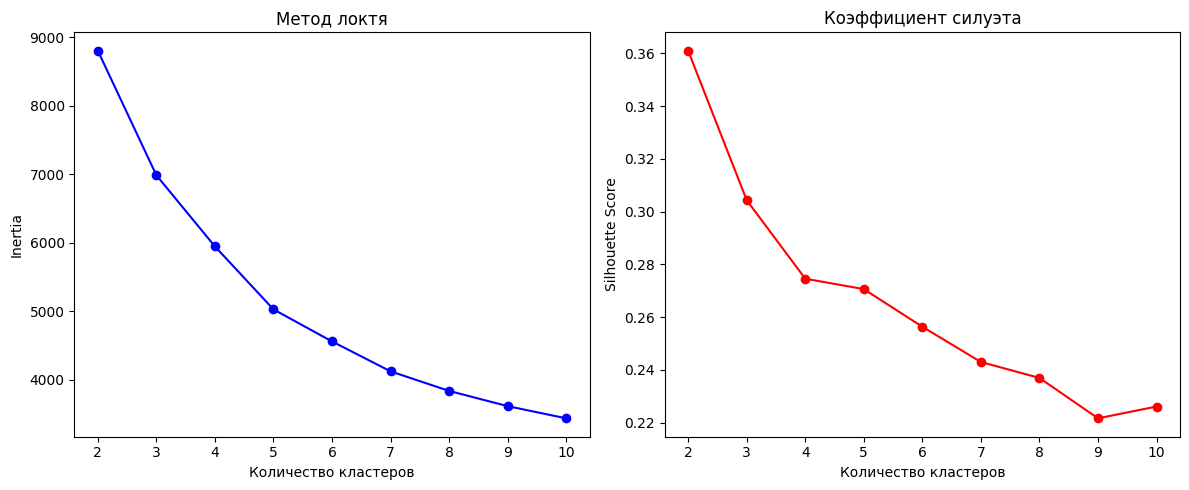

Оптимальное количество кластеров по силуэту: 2
K-means время обучения: 0.0282 сек
K-means Silhouette Score: 0.3610
K-means Davies-Bouldin Index: 1.0537
K-means Calinski-Harabasz Index: 2462.4165


In [12]:
# K-means кластеризация
# Подбор оптимального количества кластеров с помощью метода локтя
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_))

# Визуализация метода локтя
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.title('Коэффициент силуэта')

plt.tight_layout()
plt.show()

# Выбор оптимального k по коэффициенту силуэта
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров по силуэту: {optimal_k}")

# Обучение K-means с оптимальным k
start_time = time.time()
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_processed)
kmeans_time = time.time() - start_time

# Вычисление метрик для K-means
kmeans_silhouette = silhouette_score(X_processed, kmeans_labels)
kmeans_db = davies_bouldin_score(X_processed, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_processed, kmeans_labels)

print(f"K-means время обучения: {kmeans_time:.4f} сек")
print(f"K-means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"K-means Davies-Bouldin Index: {kmeans_db:.4f}")
print(f"K-means Calinski-Harabasz Index: {kmeans_ch:.4f}")


Ward linkage:
Время обучения: 0.4621 сек
Silhouette Score: 0.3427
Davies-Bouldin Index: 1.0632
Calinski-Harabasz Index: 2220.7075

Complete linkage:
Время обучения: 0.5165 сек
Silhouette Score: 0.6834
Davies-Bouldin Index: 0.6873
Calinski-Harabasz Index: 472.5255

Average linkage:
Время обучения: 0.4708 сек
Silhouette Score: 0.8148
Davies-Bouldin Index: 0.3365
Calinski-Harabasz Index: 262.4982

Single linkage:
Время обучения: 0.2764 сек
Silhouette Score: 0.8518
Davies-Bouldin Index: 0.1021
Calinski-Harabasz Index: 69.7860


<Figure size 1500x1000 with 0 Axes>

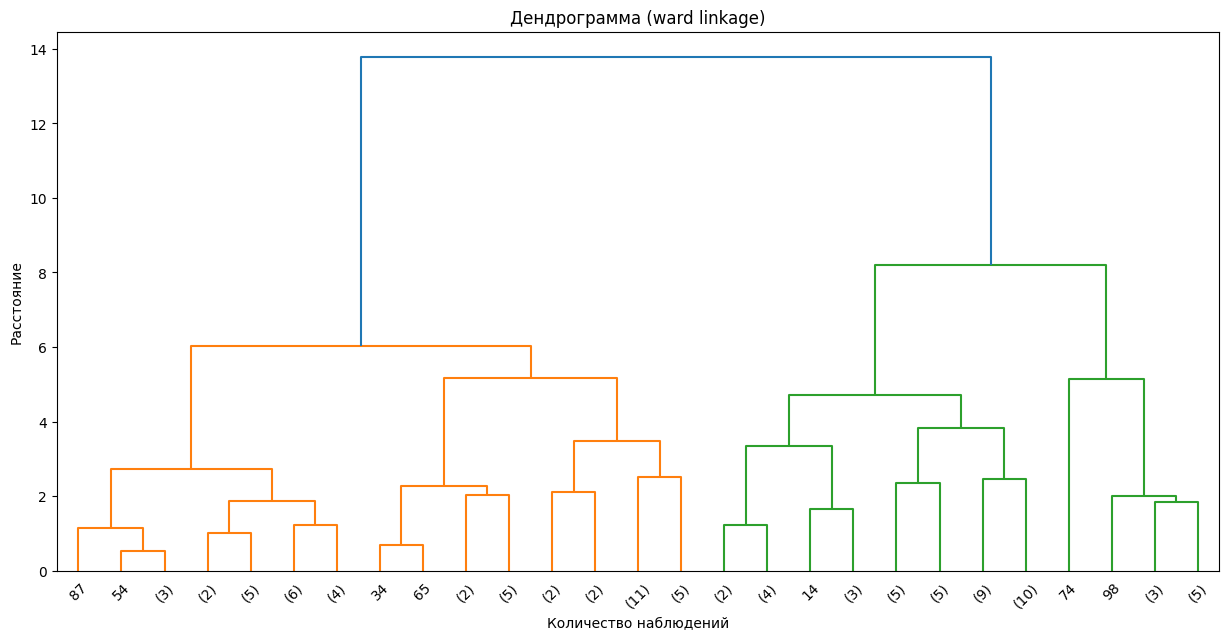

In [13]:
# Иерархическая кластеризация
# Тестирование разных методов linkage
linkage_methods = ['ward', 'complete', 'average', 'single']
linkage_results = {}

plt.figure(figsize=(15, 10))

for i, method in enumerate(linkage_methods, 1):
    start_time = time.time()
    agg_clustering = AgglomerativeClustering(
        n_clusters=optimal_k, 
        linkage=method,
        compute_distances=True
    )
    agg_labels = agg_clustering.fit_predict(X_processed)
    agg_time = time.time() - start_time
    
    # Вычисление метрик
    agg_silhouette = silhouette_score(X_processed, agg_labels)
    agg_db = davies_bouldin_score(X_processed, agg_labels)
    agg_ch = calinski_harabasz_score(X_processed, agg_labels)
    
    linkage_results[method] = {
        'labels': agg_labels,
        'time': agg_time,
        'silhouette': agg_silhouette,
        'db': agg_db,
        'ch': agg_ch
    }
    
    print(f"\n{method.title()} linkage:")
    print(f"Время обучения: {agg_time:.4f} сек")
    print(f"Silhouette Score: {agg_silhouette:.4f}")
    print(f"Davies-Bouldin Index: {agg_db:.4f}")
    print(f"Calinski-Harabasz Index: {agg_ch:.4f}")

# Построение дендрограммы для ward linkage (только для небольшой выборки данных)
plt.figure(figsize=(15, 7))
sample_indices = np.random.choice(len(X_processed), 100, replace=False)
sample_data = X_processed[sample_indices]

linkage_matrix = linkage(sample_data, method='ward')
dendrogram(linkage_matrix, truncate_mode='level', p=4)
plt.title('Дендрограмма (ward linkage)')
plt.xlabel('Количество наблюдений')
plt.ylabel('Расстояние')
plt.show()

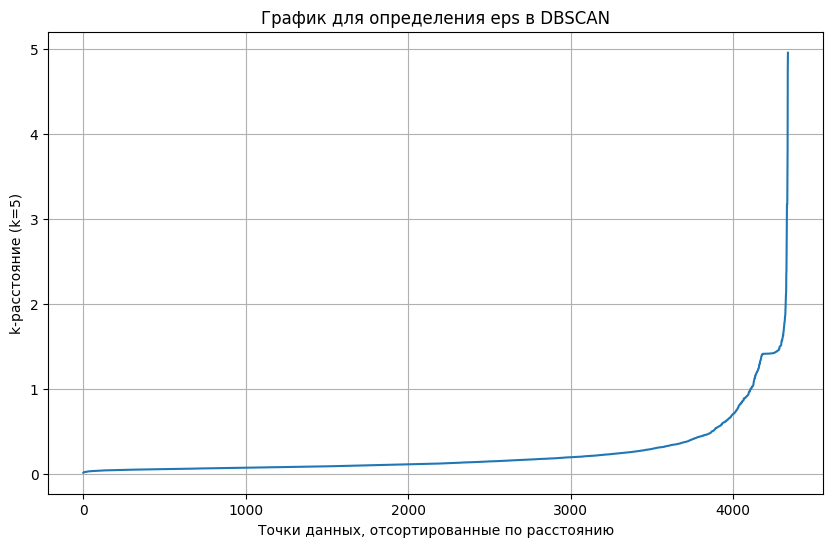


Лучшие параметры DBSCAN: eps=0.5, min_samples=20, silhouette=0.2981

DBSCAN время обучения: 0.0442 сек
Количество кластеров: 2
Количество шумовых точек: 630
DBSCAN Silhouette Score: 0.2981
DBSCAN Davies-Bouldin Index: 1.1253
DBSCAN Calinski-Harabasz Index: 1944.9631


In [14]:
# DBSCAN кластеризация
# Подбор параметров eps с помощью метода k-расстояний
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_processed)
distances, indices = nn.kneighbors(X_processed)
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Точки данных, отсортированные по расстоянию')
plt.ylabel('k-расстояние (k=5)')
plt.title('График для определения eps в DBSCAN')
plt.grid(True)
plt.show()

# Выбор eps по "изгибу" графика
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10, 15, 20]

best_eps = None
best_min_samples = None
best_silhouette = -1

for eps in eps_values:
    for min_samples in min_samples_values:
        start_time = time.time()
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_processed)
        
        # Проверка наличия как минимум двух кластеров
        if len(set(dbscan_labels)) > 1 and -1 in set(dbscan_labels):
            try:
                silhouette = silhouette_score(X_processed[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
                if silhouette > best_silhouette:
                    best_silhouette = silhouette
                    best_eps = eps
                    best_min_samples = min_samples
            except:
                continue

print(f"\nЛучшие параметры DBSCAN: eps={best_eps}, min_samples={best_min_samples}, silhouette={best_silhouette:.4f}")

# Обучение DBSCAN с лучшими параметрами
start_time = time.time()
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_processed)
dbscan_time = time.time() - start_time

# Количество кластеров и количество шумовых точек
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN время обучения: {dbscan_time:.4f} сек")
print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек: {n_noise}")

# Вычисление метрик для точек, не являющихся шумом
if n_clusters > 1:
    core_samples = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(X_processed[core_samples], dbscan_labels[core_samples])
    dbscan_db = davies_bouldin_score(X_processed[core_samples], dbscan_labels[core_samples])
    dbscan_ch = calinski_harabasz_score(X_processed[core_samples], dbscan_labels[core_samples])
    
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"DBSCAN Davies-Bouldin Index: {dbscan_db:.4f}")
    print(f"DBSCAN Calinski-Harabasz Index: {dbscan_ch:.4f}")
else:
    dbscan_silhouette = None
    dbscan_db = None
    dbscan_ch = None

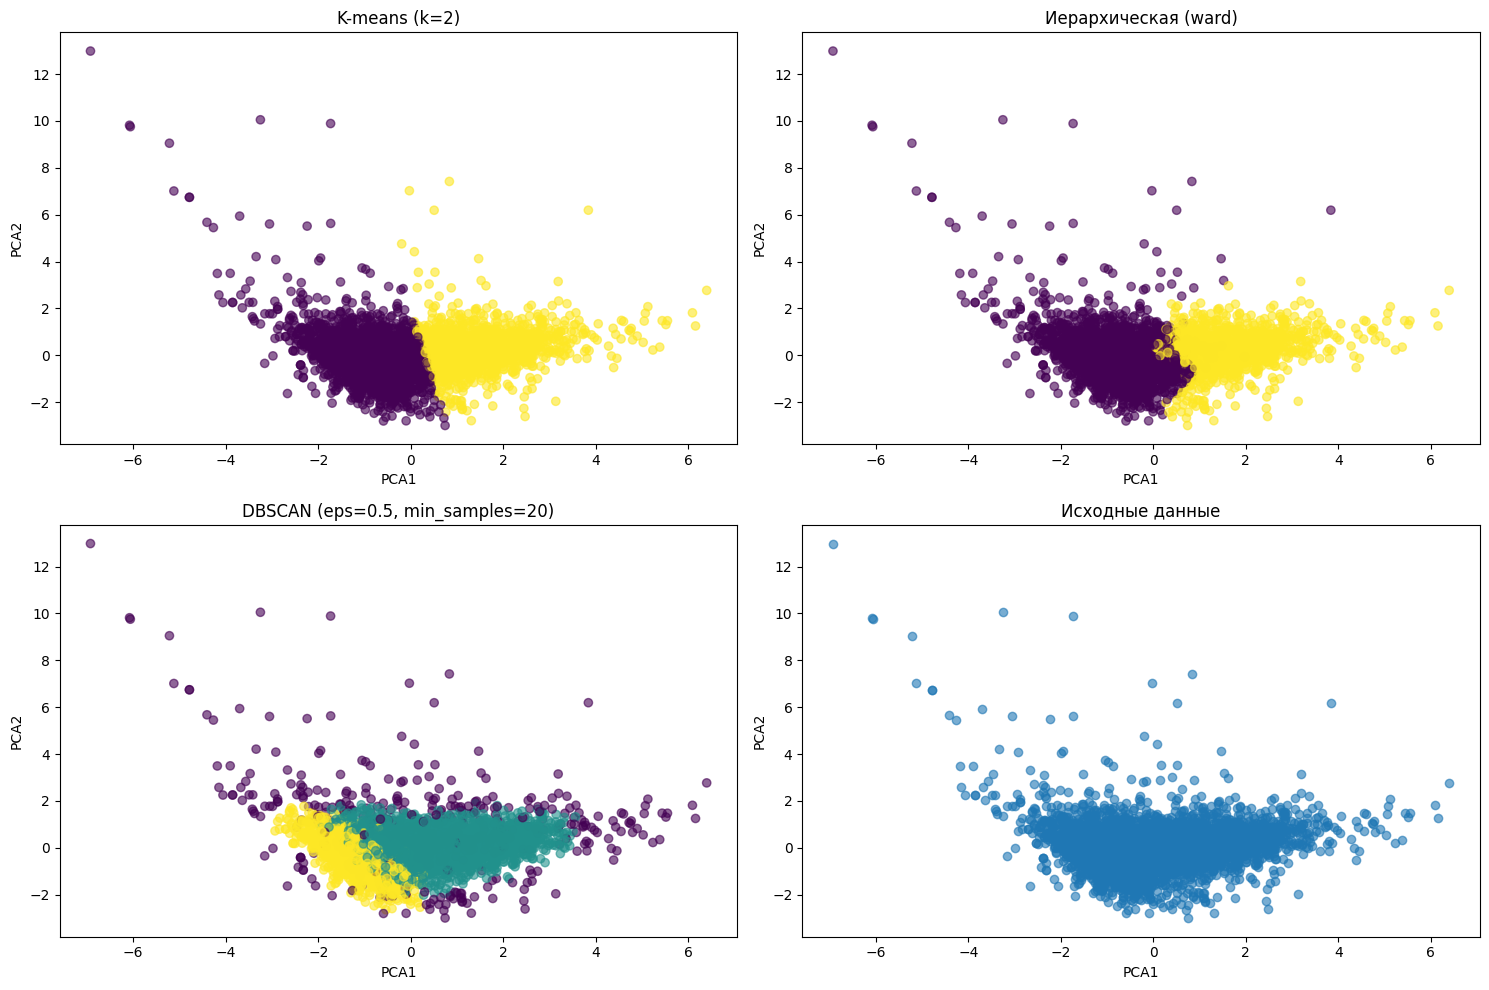

In [15]:
# Визуализация результатов кластеризации (используем PCA для понижения до 2D)
pca_vis = PCA(n_components=2, random_state=42)
X_pca = pca_vis.fit_transform(X_processed)

plt.figure(figsize=(15, 10))

# K-means визуализация
plt.subplot(2, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
plt.title(f'K-means (k={optimal_k})')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

# Иерархическая кластеризация (ward) визуализация
plt.subplot(2, 2, 2)
ward_labels = linkage_results['ward']['labels']
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=ward_labels, cmap='viridis', alpha=0.6)
plt.title('Иерархическая (ward)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

# DBSCAN визуализация
plt.subplot(2, 2, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6)
plt.title(f'DBSCAN (eps={best_eps}, min_samples={best_min_samples})')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

# Исходные данные для сравнения
plt.subplot(2, 2, 4)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.title('Исходные данные')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

plt.tight_layout()
plt.show()

Доля объясненной дисперсии (PCA 2D): 0.8801739525023129
Доля объясненной дисперсии (PCA 3D): 0.9458847705140561
t-SNE 2D время выполнения: 11.08 сек
t-SNE 3D время выполнения: 23.39 сек
UMAP 2D время выполнения: 32.09 сек
UMAP 3D время выполнения: 4.13 сек


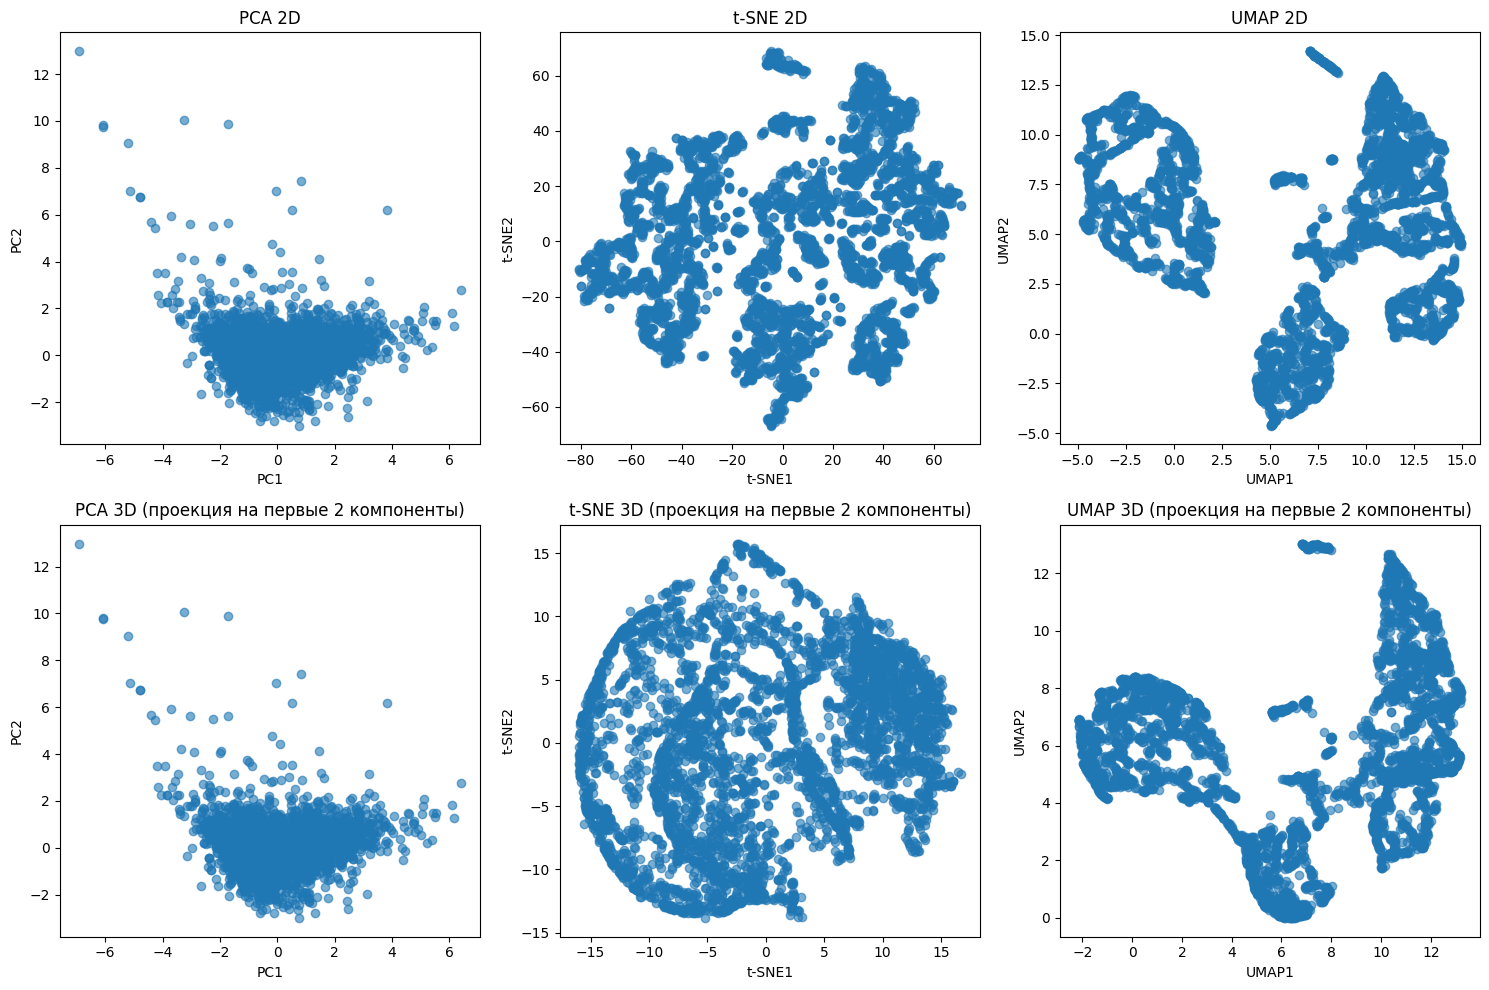

In [16]:
# PCA до 2 и 3 компонент
pca_2d = PCA(n_components=2, random_state=42)
pca_3d = PCA(n_components=3, random_state=42)

X_pca_2d = pca_2d.fit_transform(X_processed)
X_pca_3d = pca_3d.fit_transform(X_processed)

print("Доля объясненной дисперсии (PCA 2D):", pca_2d.explained_variance_ratio_.sum())
print("Доля объясненной дисперсии (PCA 3D):", pca_3d.explained_variance_ratio_.sum())

# t-SNE до 2 и 3 компонент
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30)

start_time = time.time()
X_tsne_2d = tsne_2d.fit_transform(X_processed)
tsne_2d_time = time.time() - start_time

start_time = time.time()
X_tsne_3d = tsne_3d.fit_transform(X_processed)
tsne_3d_time = time.time() - start_time

print(f"t-SNE 2D время выполнения: {tsne_2d_time:.2f} сек")
print(f"t-SNE 3D время выполнения: {tsne_3d_time:.2f} сек")

# UMAP до 2 и 3 компонент
reducer_2d = umap.UMAP(n_components=2, random_state=42)
reducer_3d = umap.UMAP(n_components=3, random_state=42)

start_time = time.time()
X_umap_2d = reducer_2d.fit_transform(X_processed)
umap_2d_time = time.time() - start_time

start_time = time.time()
X_umap_3d = reducer_3d.fit_transform(X_processed)
umap_3d_time = time.time() - start_time

print(f"UMAP 2D время выполнения: {umap_2d_time:.2f} сек")
print(f"UMAP 3D время выполнения: {umap_3d_time:.2f} сек")

# Визуализация результатов снижения размерности
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.6)
plt.title('PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(2, 3, 2)
plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], alpha=0.6)
plt.title('t-SNE 2D')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')

plt.subplot(2, 3, 3)
plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], alpha=0.6)
plt.title('UMAP 2D')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

# 3D визуализация для PCA, t-SNE, UMAP с использованием 2D проекций
plt.subplot(2, 3, 4)
plt.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], alpha=0.6)
plt.title('PCA 3D (проекция на первые 2 компоненты)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(2, 3, 5)
plt.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], alpha=0.6)
plt.title('t-SNE 3D (проекция на первые 2 компоненты)')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')

plt.subplot(2, 3, 6)
plt.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], alpha=0.6)
plt.title('UMAP 3D (проекция на первые 2 компоненты)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

plt.tight_layout()
plt.show()

In [ ]:
# Словарь для хранения результатов
reduced_results = {
    'PCA_2D': X_pca_2d,
    'PCA_3D': X_pca_3d,
    'TSNE_2D': X_tsne_2d,
    'TSNE_3D': X_tsne_3d,
    'UMAP_2D': X_umap_2d,
    'UMAP_3D': X_umap_3d
}

# Функция для кластеризации на пониженных данных
def cluster_on_reduced(reduced_data, method_name, original_optimal_k=optimal_k):
    results = {}
    
    # K-means
    start_time = time.time()
    kmeans_reduced = KMeans(n_clusters=original_optimal_k, random_state=42, n_init=10)
    kmeans_labels_reduced = kmeans_reduced.fit_predict(reduced_data)
    kmeans_time_reduced = time.time() - start_time
    
    kmeans_silhouette_reduced = silhouette_score(reduced_data, kmeans_labels_reduced)
    kmeans_db_reduced = davies_bouldin_score(reduced_data, kmeans_labels_reduced)
    kmeans_ch_reduced = calinski_harabasz_score(reduced_data, kmeans_labels_reduced)
    
    # Иерархическая кластеризация (ward)
    start_time = time.time()
    agg_reduced = AgglomerativeClustering(n_clusters=original_optimal_k, linkage='ward')
    agg_labels_reduced = agg_reduced.fit_predict(reduced_data)
    agg_time_reduced = time.time() - start_time
    
    agg_silhouette_reduced = silhouette_score(reduced_data, agg_labels_reduced)
    agg_db_reduced = davies_bouldin_score(reduced_data, agg_labels_reduced)
    agg_ch_reduced = calinski_harabasz_score(reduced_data, agg_labels_reduced)
    
    # DBSCAN - используем параметры, подобранные ранее
    start_time = time.time()
    dbscan_reduced = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    dbscan_labels_reduced = dbscan_reduced.fit_predict(reduced_data)
    dbscan_time_reduced = time.time() - start_time
    
    n_clusters_reduced = len(set(dbscan_labels_reduced)) - (1 if -1 in dbscan_labels_reduced else 0)
    
    if n_clusters_reduced > 1:
        core_samples = dbscan_labels_reduced != -1
        if sum(core_samples) > 0 and len(set(dbscan_labels_reduced[core_samples])) > 1:
            dbscan_silhouette_reduced = silhouette_score(reduced_data[core_samples], dbscan_labels_reduced[core_samples])
            dbscan_db_reduced = davies_bouldin_score(reduced_data[core_samples], dbscan_labels_reduced[core_samples])
            dbscan_ch_reduced = calinski_harabasz_score(reduced_data[core_samples], dbscan_labels_reduced[core_samples])
        else:
            dbscan_silhouette_reduced = None
            dbscan_db_reduced = None
            dbscan_ch_reduced = None
    else:
        dbscan_silhouette_reduced = None
        dbscan_db_reduced = None
        dbscan_ch_reduced = None
    
    # Сохранение результатов
    results['kmeans'] = {
        'labels': kmeans_labels_reduced,
        'time': kmeans_time_reduced,
        'silhouette': kmeans_silhouette_reduced,
        'db': kmeans_db_reduced,
        'ch': kmeans_ch_reduced
    }
    
    results['hierarchical'] = {
        'labels': agg_labels_reduced,
        'time': agg_time_reduced,
        'silhouette': agg_silhouette_reduced,
        'db': agg_db_reduced,
        'ch': agg_ch_reduced
    }
    
    results['dbscan'] = {
        'labels': dbscan_labels_reduced,
        'time': dbscan_time_reduced,
        'silhouette': dbscan_silhouette_reduced,
        'db': dbscan_db_reduced,
        'ch': dbscan_ch_reduced,
        'n_clusters': n_clusters_reduced
    }
    
    return results

# Применение кластеризации к каждому пониженному набору данных
all_reduced_cluster_results = {}

for method, data_reduced in reduced_results.items():
    print(f"\nКластеризация на данных {method}:")
    cluster_results = cluster_on_reduced(data_reduced, method)
    all_reduced_cluster_results[method] = cluster_results
    
    # Вывод результатов для K-means
    print(f"K-means (k={optimal_k}):")
    print(f"  Время обучения: {cluster_results['kmeans']['time']:.4f} сек")
    print(f"  Silhouette Score: {cluster_results['kmeans']['silhouette']:.4f}")
    print(f"  Davies-Bouldin Index: {cluster_results['kmeans']['db']:.4f}")
    print(f"  Calinski-Harabasz Index: {cluster_results['kmeans']['ch']:.4f}")
    
    # Вывод результатов для иерархической кластеризации
    print(f"Иерархическая кластеризация (ward):")
    print(f"  Время обучения: {cluster_results['hierarchical']['time']:.4f} сек")
    print(f"  Silhouette Score: {cluster_results['hierarchical']['silhouette']:.4f}")
    print(f"  Davies-Bouldin Index: {cluster_results['hierarchical']['db']:.4f}")
    print(f"  Calinski-Harabasz Index: {cluster_results['hierarchical']['ch']:.4f}")
    
    # Вывод результатов для DBSCAN
    print(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}):")
    print(f"  Время обучения: {cluster_results['dbscan']['time']:.4f} сек")
    print(f"  Количество кластеров: {cluster_results['dbscan']['n_clusters']}")
    if cluster_results['dbscan']['silhouette'] is not None:
        print(f"  Silhouette Score: {cluster_results['dbscan']['silhouette']:.4f}")
        print(f"  Davies-Bouldin Index: {cluster_results['dbscan']['db']:.4f}")
        print(f"  Calinski-Harabasz Index: {cluster_results['dbscan']['ch']:.4f}")


Кластеризация на данных PCA_2D:
K-means (k=2):
  Время обучения: 0.0253 сек
  Silhouette Score: 0.4160
  Davies-Bouldin Index: 0.9058
  Calinski-Harabasz Index: 3030.7955
Иерархическая кластеризация (ward):
  Время обучения: 0.3748 сек
  Silhouette Score: 0.3935
  Davies-Bouldin Index: 0.9012
  Calinski-Harabasz Index: 2512.6215
DBSCAN (eps=0.5, min_samples=20):
  Время обучения: 0.0575 сек
  Количество кластеров: 1

Кластеризация на данных PCA_3D:
K-means (k=2):
  Время обучения: 0.0181 сек
  Silhouette Score: 0.3805
  Davies-Bouldin Index: 0.9984
  Calinski-Harabasz Index: 2690.5115
Иерархическая кластеризация (ward):
  Время обучения: 0.6041 сек
  Silhouette Score: 0.3524
  Davies-Bouldin Index: 1.0677
  Calinski-Harabasz Index: 2487.8066
DBSCAN (eps=0.5, min_samples=20):
  Время обучения: 0.0586 сек
  Количество кластеров: 1

Кластеризация на данных TSNE_2D:
K-means (k=2):
  Время обучения: 0.0215 сек
  Silhouette Score: 0.4324
  Davies-Bouldin Index: 0.9388
  Calinski-Harabasz In

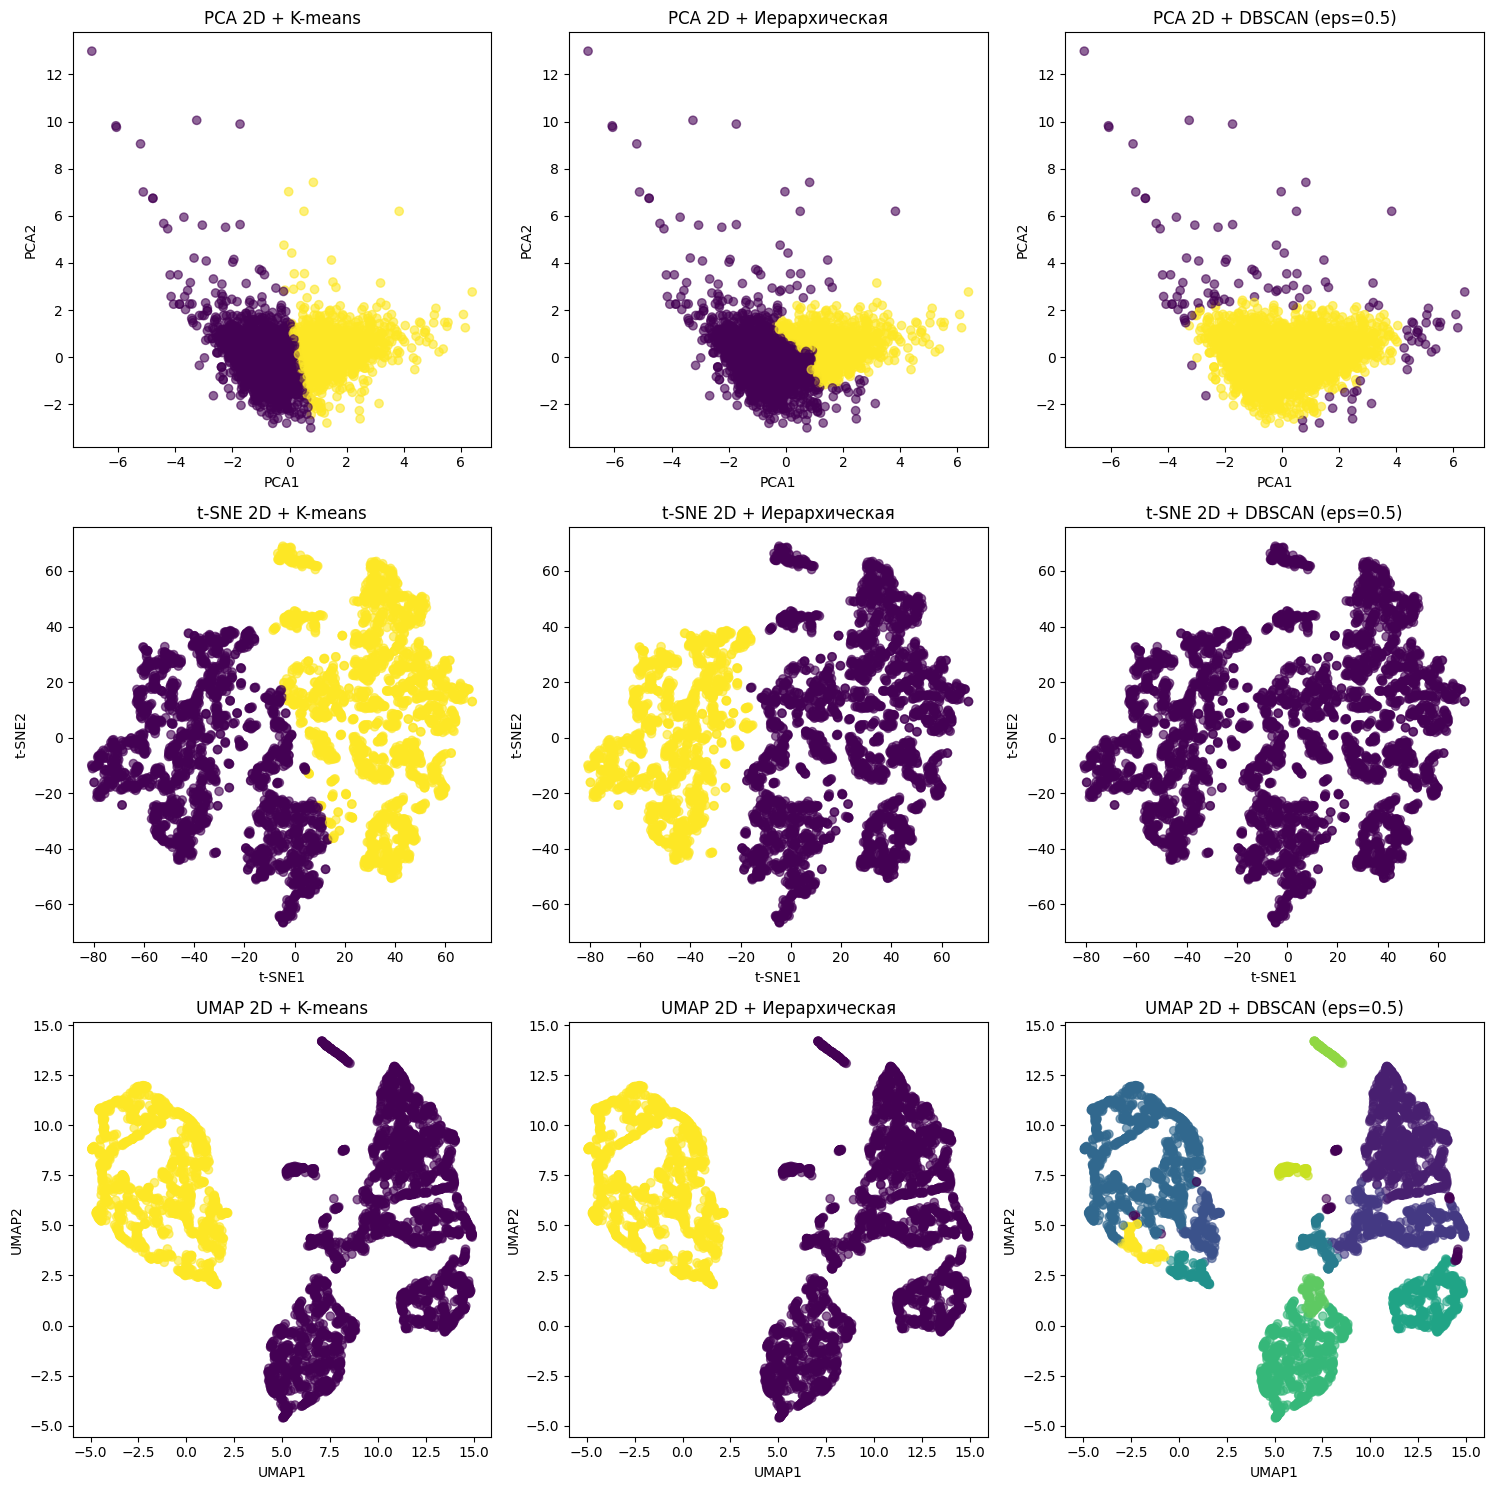

In [18]:
# Визуализация кластеров после снижения размерности
plt.figure(figsize=(20, 15))

# Визуализация для PCA 2D
plt.subplot(3, 4, 1)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=all_reduced_cluster_results['PCA_2D']['kmeans']['labels'], cmap='viridis', alpha=0.6)
plt.title('PCA 2D + K-means')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

plt.subplot(3, 4, 2)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=all_reduced_cluster_results['PCA_2D']['hierarchical']['labels'], cmap='viridis', alpha=0.6)
plt.title('PCA 2D + Иерархическая')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

plt.subplot(3, 4, 3)
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=all_reduced_cluster_results['PCA_2D']['dbscan']['labels'], cmap='viridis', alpha=0.6)
plt.title(f'PCA 2D + DBSCAN (eps={best_eps})')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

# Визуализация для t-SNE 2D
plt.subplot(3, 4, 5)
plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=all_reduced_cluster_results['TSNE_2D']['kmeans']['labels'], cmap='viridis', alpha=0.6)
plt.title('t-SNE 2D + K-means')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')

plt.subplot(3, 4, 6)
plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=all_reduced_cluster_results['TSNE_2D']['hierarchical']['labels'], cmap='viridis', alpha=0.6)
plt.title('t-SNE 2D + Иерархическая')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')

plt.subplot(3, 4, 7)
plt.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=all_reduced_cluster_results['TSNE_2D']['dbscan']['labels'], cmap='viridis', alpha=0.6)
plt.title(f't-SNE 2D + DBSCAN (eps={best_eps})')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')

# Визуализация для UMAP 2D
plt.subplot(3, 4, 9)
plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=all_reduced_cluster_results['UMAP_2D']['kmeans']['labels'], cmap='viridis', alpha=0.6)
plt.title('UMAP 2D + K-means')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

plt.subplot(3, 4, 10)
plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=all_reduced_cluster_results['UMAP_2D']['hierarchical']['labels'], cmap='viridis', alpha=0.6)
plt.title('UMAP 2D + Иерархическая')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

plt.subplot(3, 4, 11)
plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=all_reduced_cluster_results['UMAP_2D']['dbscan']['labels'], cmap='viridis', alpha=0.6)
plt.title(f'UMAP 2D + DBSCAN (eps={best_eps})')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

plt.tight_layout()
plt.show()

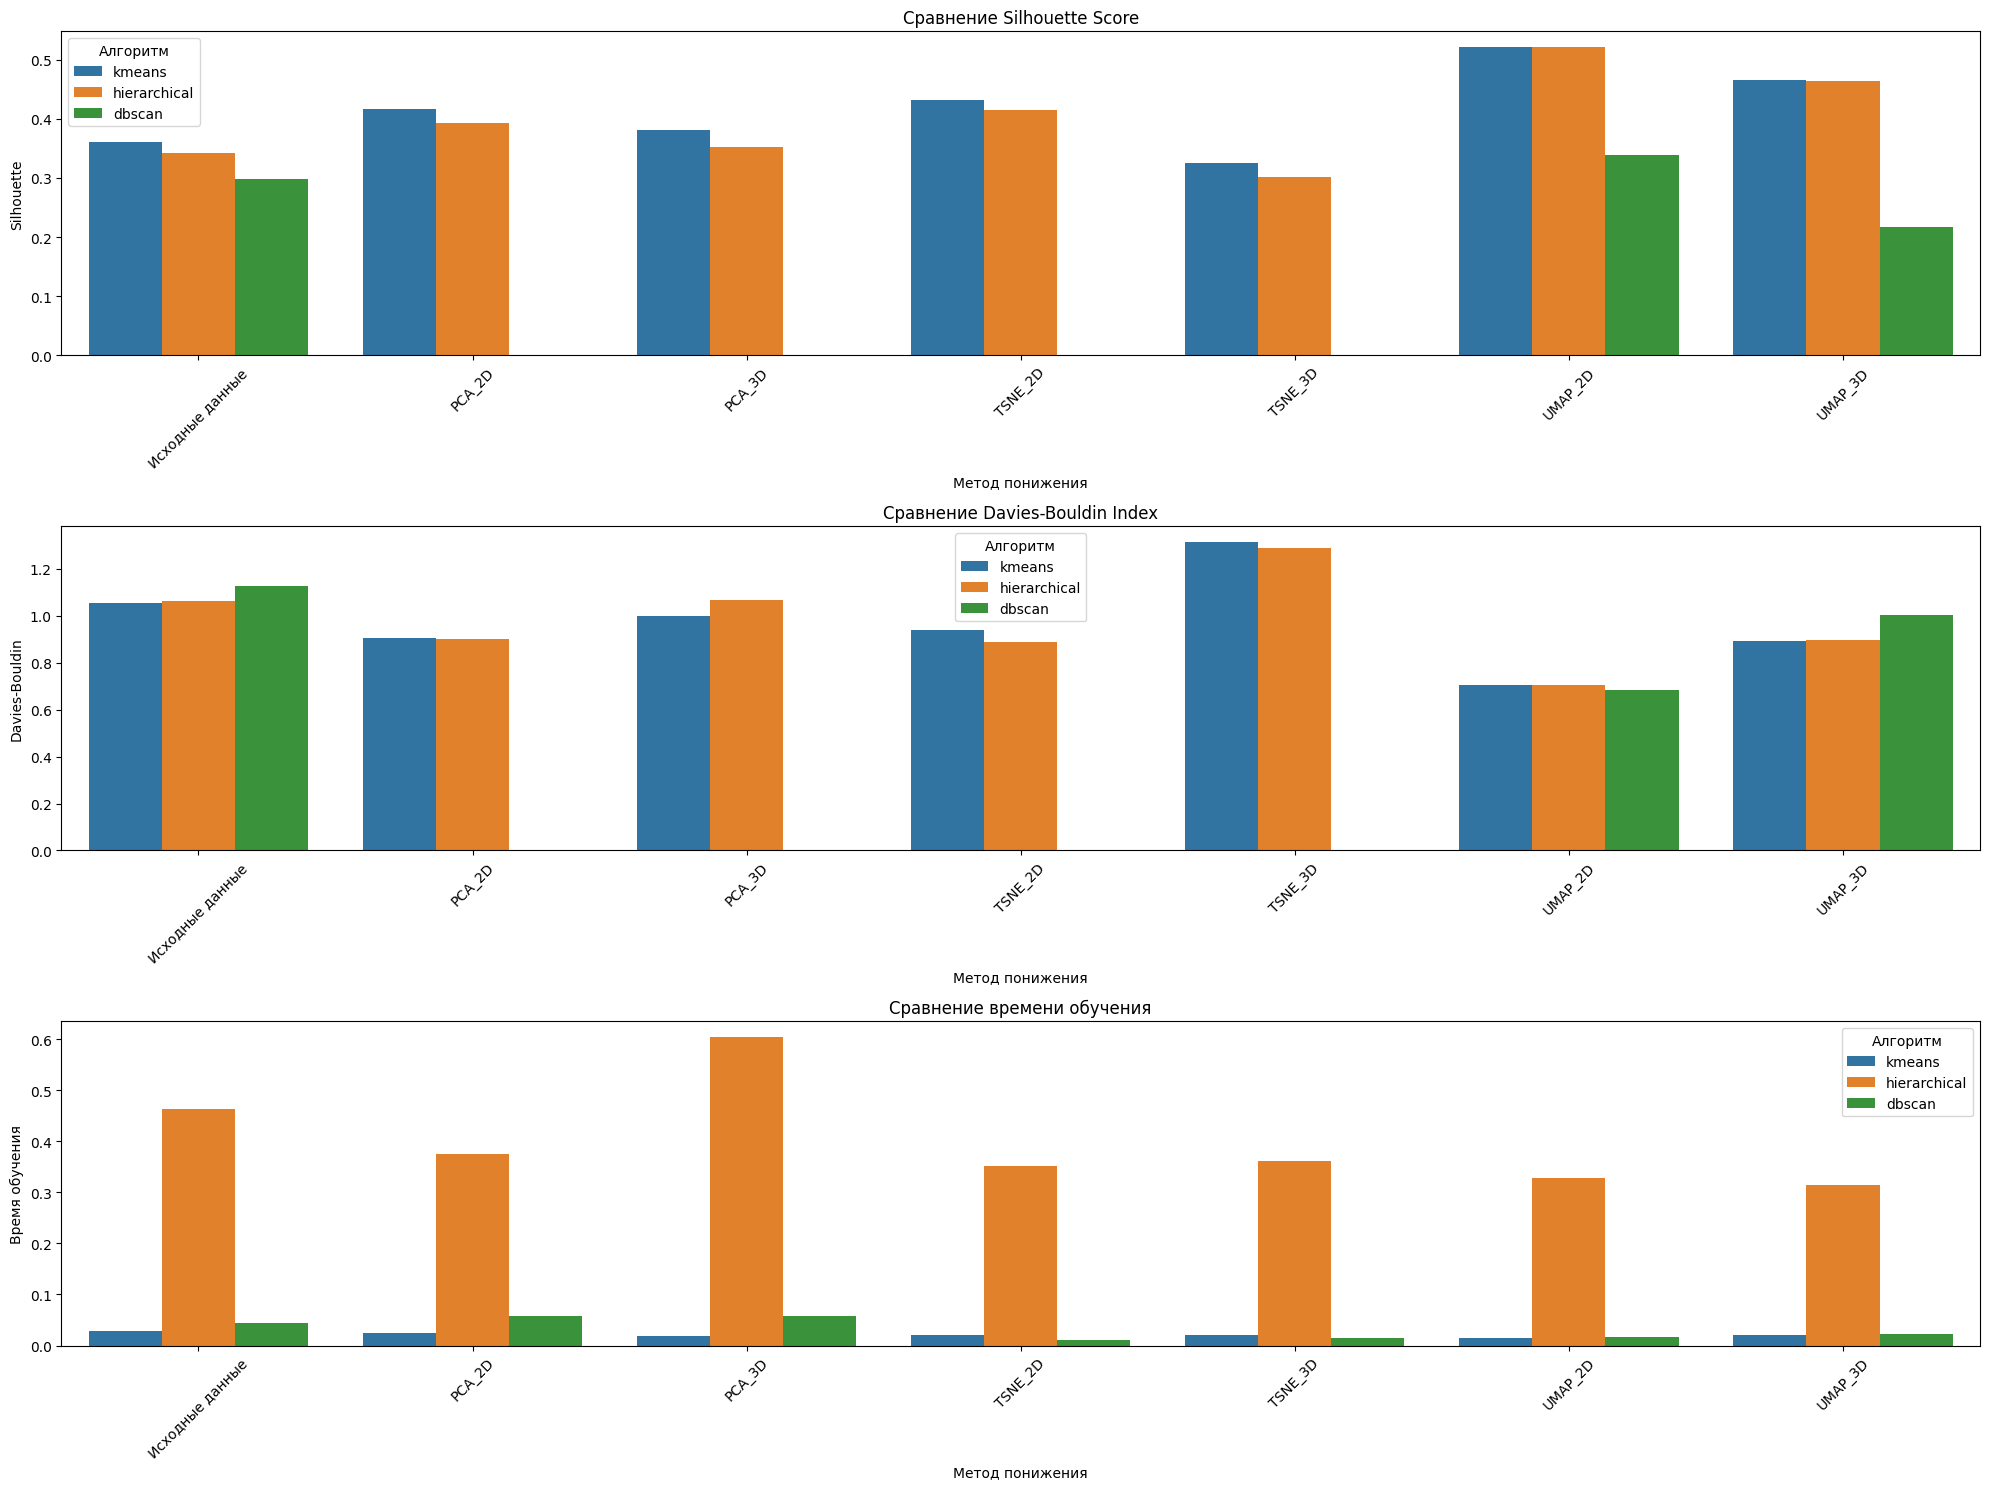

In [19]:
# Сравнение метрик до и после снижения размерности
original_results = {
    'kmeans': {
        'silhouette': kmeans_silhouette,
        'db': kmeans_db,
        'ch': kmeans_ch,
        'time': kmeans_time
    },
    'hierarchical': {
        'silhouette': linkage_results['ward']['silhouette'],
        'db': linkage_results['ward']['db'],
        'ch': linkage_results['ward']['ch'],
        'time': linkage_results['ward']['time']
    },
    'dbscan': {
        'silhouette': dbscan_silhouette if dbscan_silhouette is not None else 0,
        'db': dbscan_db if dbscan_db is not None else 0,
        'ch': dbscan_ch if dbscan_ch is not None else 0,
        'time': dbscan_time
    }
}

# Создание таблицы для сравнения
comparison_data = []

for method, results in all_reduced_cluster_results.items():
    for algo in ['kmeans', 'hierarchical', 'dbscan']:
        comparison_data.append({
            'Метод понижения': method,
            'Алгоритм': algo,
            'Silhouette': results[algo]['silhouette'],
            'Davies-Bouldin': results[algo]['db'],
            'Calinski-Harabasz': results[algo]['ch'],
            'Время обучения': results[algo]['time']
        })

# Сравнение с исходными данными
original_comparison = []
for algo in ['kmeans', 'hierarchical', 'dbscan']:
    original_comparison.append({
        'Метод понижения': 'Исходные данные',
        'Алгоритм': algo,
        'Silhouette': original_results[algo]['silhouette'],
        'Davies-Bouldin': original_results[algo]['db'],
        'Calinski-Harabasz': original_results[algo]['ch'],
        'Время обучения': original_results[algo]['time']
    })

# Объединение данных
comparison_df = pd.DataFrame(original_comparison + comparison_data)

# Визуализация сравнения метрик
plt.figure(figsize=(20, 15))

# Silhouette Score
plt.subplot(3, 1, 1)
sns.barplot(x='Метод понижения', y='Silhouette', hue='Алгоритм', data=comparison_df)
plt.title('Сравнение Silhouette Score')
plt.xticks(rotation=45)

# Davies-Bouldin Index (меньше - лучше)
plt.subplot(3, 1, 2)
sns.barplot(x='Метод понижения', y='Davies-Bouldin', hue='Алгоритм', data=comparison_df)
plt.title('Сравнение Davies-Bouldin Index')
plt.xticks(rotation=45)

# Время обучения
plt.subplot(3, 1, 3)
sns.barplot(x='Метод понижения', y='Время обучения', hue='Алгоритм', data=comparison_df)
plt.title('Сравнение времени обучения')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

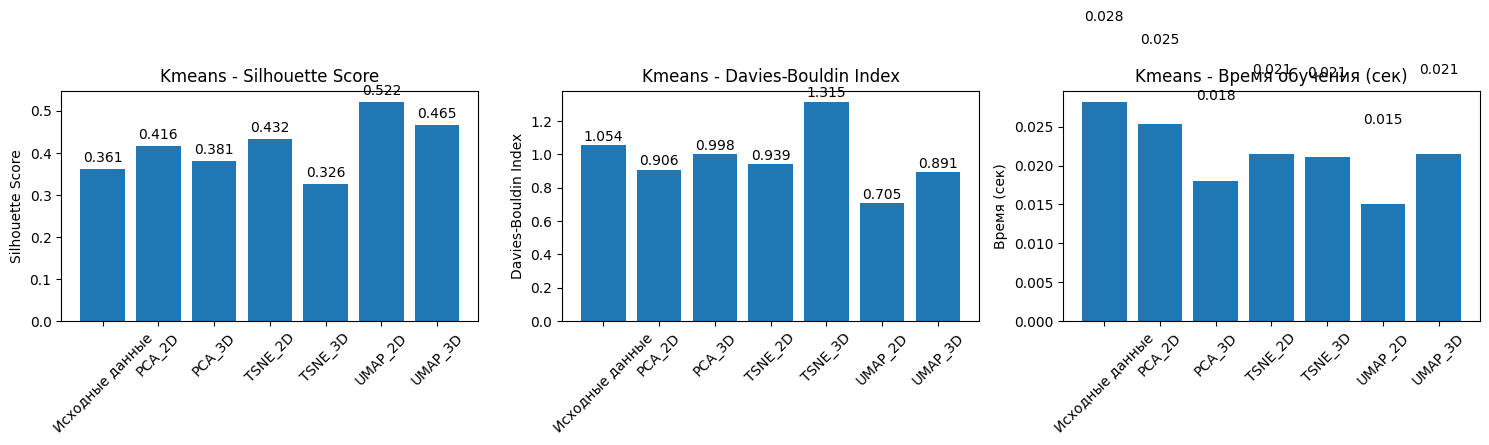

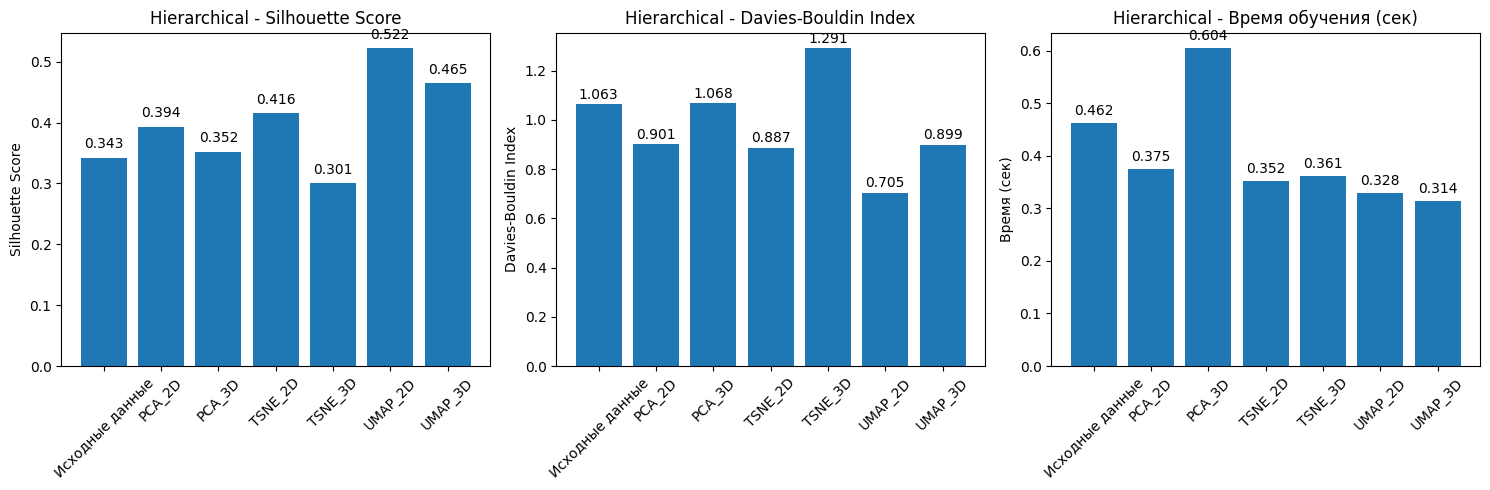

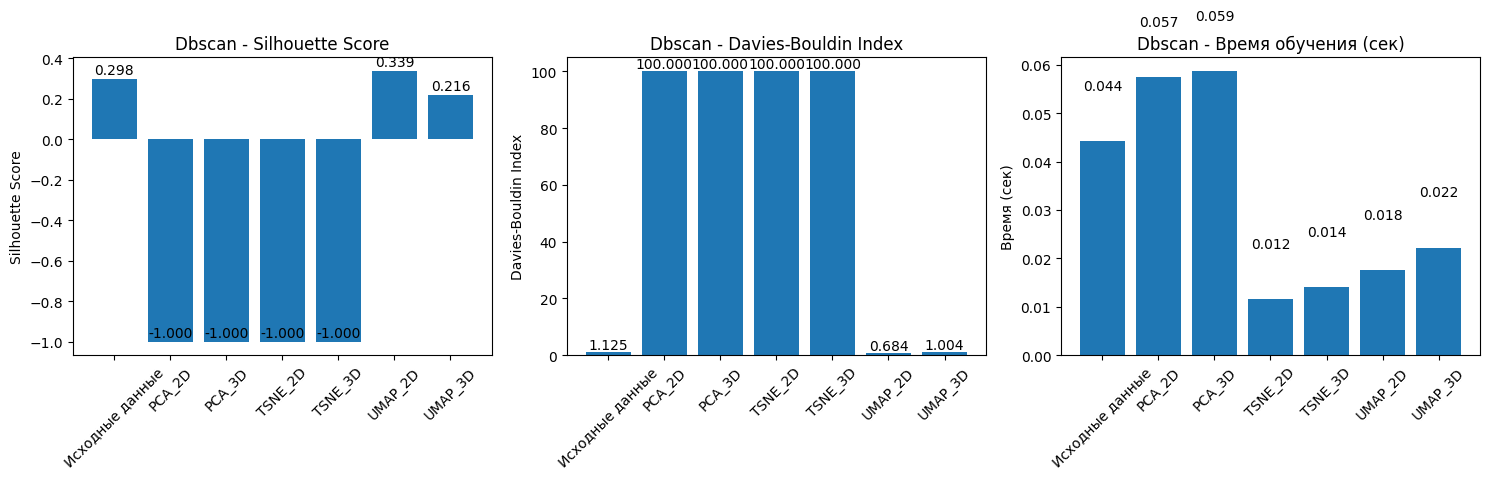

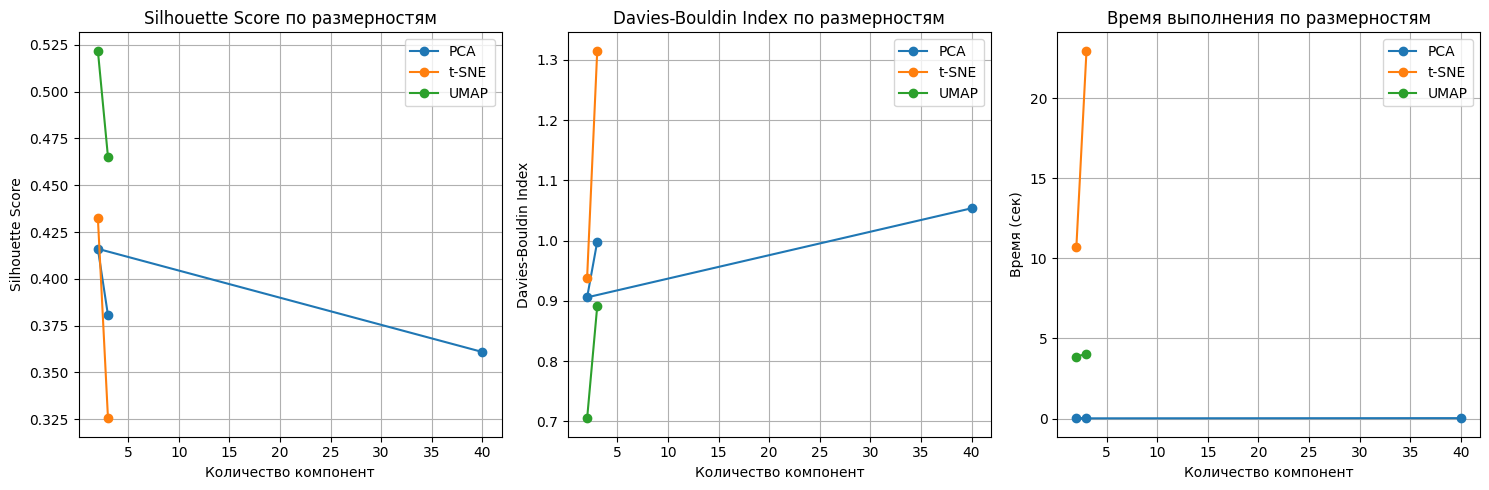

In [20]:
# Сравнение метрик по алгоритмам
algorithms = ['kmeans', 'hierarchical', 'dbscan']
metrics = ['silhouette', 'db', 'ch']

for algo in algorithms:
    plt.figure(figsize=(15, 5))
    
    # Сравнение Silhouette
    plt.subplot(1, 3, 1)
    methods = ['Исходные данные'] + list(all_reduced_cluster_results.keys())
    silhouettes = [original_results[algo]['silhouette'] if original_results[algo]['silhouette'] is not None else -1]
    
    for method in all_reduced_cluster_results:
        val = all_reduced_cluster_results[method][algo]['silhouette']
        silhouettes.append(val if val is not None else -1)
    
    bars = plt.bar(methods, silhouettes)
    plt.title(f'{algo.capitalize()} - Silhouette Score')
    plt.xticks(rotation=45)
    plt.ylabel('Silhouette Score')
    
    # Добавление значений над столбцами
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom')
    
    # Сравнение Davies-Bouldin (меньше - лучше)
    plt.subplot(1, 3, 2)
    db_values = [original_results[algo]['db'] if original_results[algo]['db'] is not None else 100.0]
    for method in all_reduced_cluster_results:
        val = all_reduced_cluster_results[method][algo]['db']
        db_values.append(val if val is not None else 100.0)

    bars = plt.bar(methods, db_values)
    plt.title(f'{algo.capitalize()} - Davies-Bouldin Index')
    plt.xticks(rotation=45)
    plt.ylabel('Davies-Bouldin Index')
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom')
    
    # Сравнение времени обучения
    plt.subplot(1, 3, 3)
    times = [original_results[algo]['time'] if original_results[algo]['time'] is not None else 0.0]
    for method in all_reduced_cluster_results:
        val = all_reduced_cluster_results[method][algo]['time']
        times.append(val if val is not None else 0.0)
    
    bars = plt.bar(methods, times)
    plt.title(f'{algo.capitalize()} - Время обучения (сек)')
    plt.xticks(rotation=45)
    plt.ylabel('Время (сек)')
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Визуализация зависимости качества кластеризации от размерности
dimensions = [X_processed.shape[1], 2, 3]
methods = ['PCA', 't-SNE', 'UMAP']
algo = 'kmeans'  # Анализируем для K-means

silhouette_scores_by_dim = {'PCA': [], 't-SNE': [], 'UMAP': []}
db_scores_by_dim = {'PCA': [], 't-SNE': [], 'UMAP': []}
execution_times_by_dim = {'PCA': [], 't-SNE': [], 'UMAP': []}

# Исходные данные (полная размерность)
silhouette_scores_by_dim['PCA'].append(original_results[algo]['silhouette'])
db_scores_by_dim['PCA'].append(original_results[algo]['db'])
execution_times_by_dim['PCA'].append(original_results[algo]['time'])

# PCA
for dim in [2, 3]:
    pca = PCA(n_components=dim, random_state=42)
    X_reduced = pca.fit_transform(X_processed)
    
    start_time = time.time()
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_reduced)
    exec_time = time.time() - start_time
    
    silhouette = silhouette_score(X_reduced, labels)
    db = davies_bouldin_score(X_reduced, labels)
    
    silhouette_scores_by_dim['PCA'].append(silhouette)
    db_scores_by_dim['PCA'].append(db)
    execution_times_by_dim['PCA'].append(exec_time)

# t-SNE
silhouette_scores_by_dim['t-SNE'] = [None]
db_scores_by_dim['t-SNE'] = [None]
execution_times_by_dim['t-SNE'] = [None]

for dim in [2, 3]:
    tsne = TSNE(n_components=dim, random_state=42, perplexity=30)
    start_time = time.time()
    X_reduced = tsne.fit_transform(X_processed)
    exec_time = time.time() - start_time
    
    start_time = time.time()
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_reduced)
    clustering_time = time.time() - start_time
    
    silhouette = silhouette_score(X_reduced, labels)
    db = davies_bouldin_score(X_reduced, labels)
    
    silhouette_scores_by_dim['t-SNE'].append(silhouette)
    db_scores_by_dim['t-SNE'].append(db)
    execution_times_by_dim['t-SNE'].append(exec_time + clustering_time)

# UMAP
silhouette_scores_by_dim['UMAP'] = [None] 
db_scores_by_dim['UMAP'] = [None]
execution_times_by_dim['UMAP'] = [None]

for dim in [2, 3]:
    reducer = umap.UMAP(n_components=dim, random_state=42)
    start_time = time.time()
    X_reduced = reducer.fit_transform(X_processed)
    exec_time = time.time() - start_time
    
    start_time = time.time()
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_reduced)
    clustering_time = time.time() - start_time
    
    silhouette = silhouette_score(X_reduced, labels)
    db = davies_bouldin_score(X_reduced, labels)
    
    silhouette_scores_by_dim['UMAP'].append(silhouette)
    db_scores_by_dim['UMAP'].append(db)
    execution_times_by_dim['UMAP'].append(exec_time + clustering_time)

# Визуализация
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for method in methods:
    x_vals = dimensions if method == 'PCA' else [2, 3]
    y_vals = silhouette_scores_by_dim[method]
    # Добавить проверку длины
    if len(x_vals) != len(y_vals):
        y_vals = y_vals[-len(x_vals):]  # Берём последние элементы
    plt.plot(x_vals, y_vals, 'o-', label=method)
plt.title('Silhouette Score по размерностям')
plt.xlabel('Количество компонент')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
for method in methods:
    x_vals = dimensions if method == 'PCA' else [2, 3]
    y_vals = db_scores_by_dim[method]
    # Добавить проверку длины
    if len(x_vals) != len(y_vals):
        y_vals = y_vals[-len(x_vals):]  # Берём последние элементы
    plt.plot(x_vals, y_vals, 'o-', label=method)
plt.title('Davies-Bouldin Index по размерностям')
plt.xlabel('Количество компонент')
plt.ylabel('Davies-Bouldin Index')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
for method in methods:
    x_vals = dimensions if method == 'PCA' else [2, 3]
    y_vals = execution_times_by_dim[method]
    if len(x_vals) != len(y_vals):
        y_vals = y_vals[-len(x_vals):] 
    # Для t-SNE и UMAP первое значение None, поэтому начинаем с индекса 1
    plt.plot(x_vals, y_vals, 'o-', label=method)
plt.title('Время выполнения по размерностям')
plt.xlabel('Количество компонент')
plt.ylabel('Время (сек)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()